<a href="https://colab.research.google.com/github/Alfasmoideen/Pdf/blob/main/irisKmean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
m

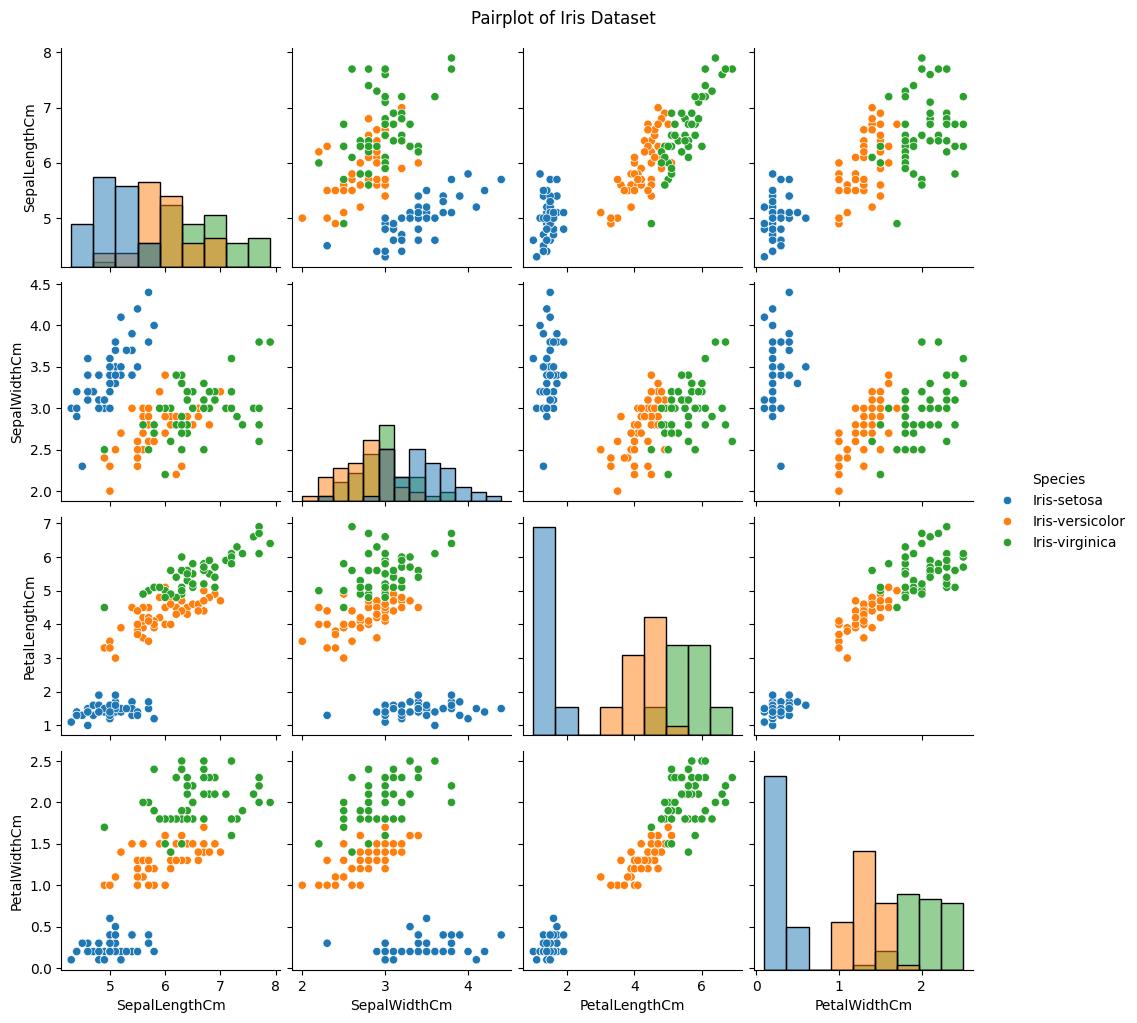

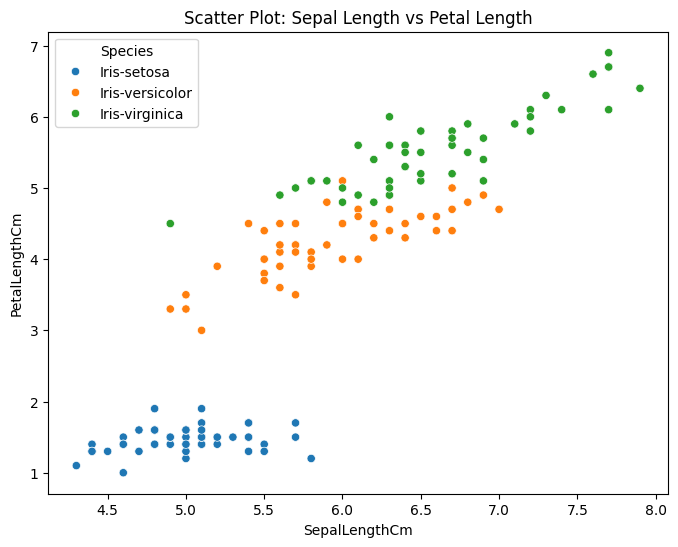

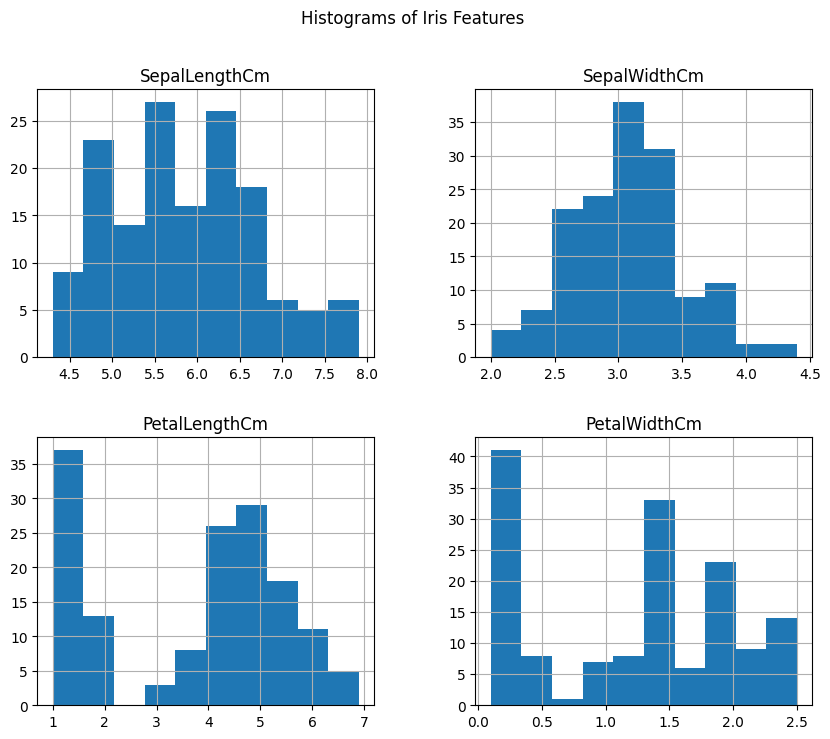

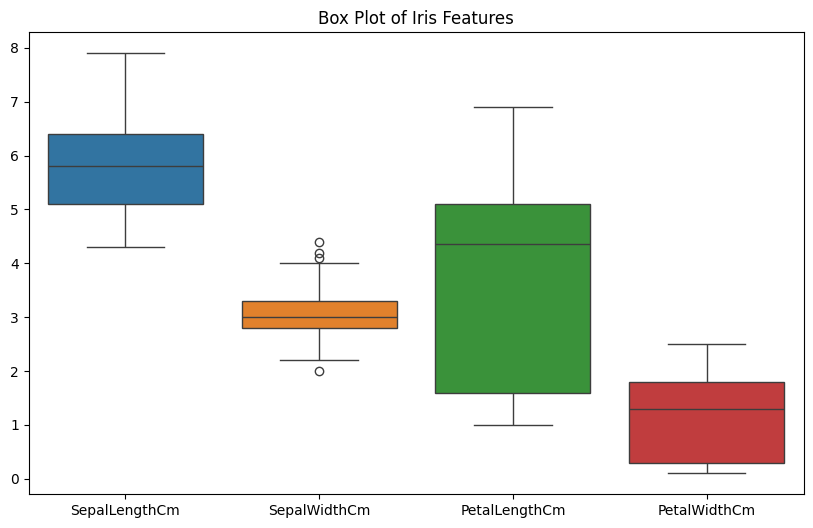

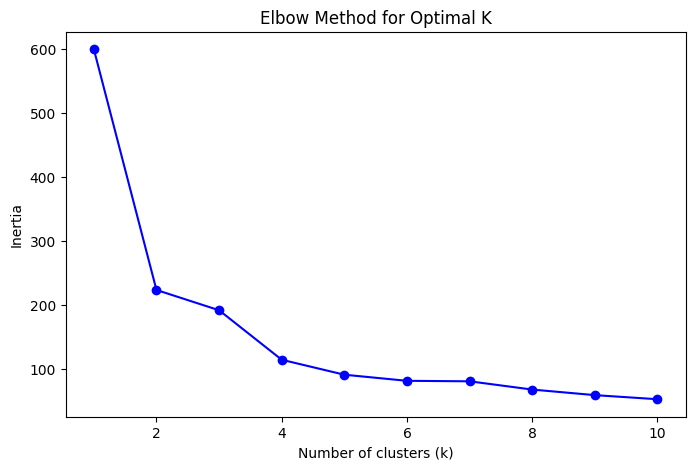

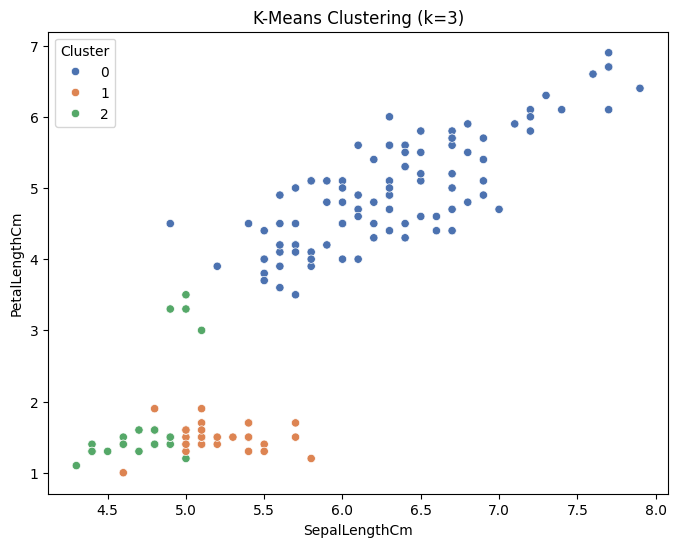

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv("/content/Iris.csv")

# Display first few rows
print("First 5 rows of dataset:\n", data.head())

# Basic info
print("\nDataset Info:")
print(data.info())

# Statistical summary
print("\nStatistical Summary:")
print(data.describe())

# Check for missing values
print("\nMissing Values:\n", data.isnull().sum())

# Drop unnecessary columns (Id)
data = data.drop(['Id'], axis=1)

# ============================
# (a) EXPLORATORY DATA ANALYSIS
# ============================

print("\nNumber of unique species:", data['Species'].nunique())
print("Species count:\n", data['Species'].value_counts())

# Pairplot to visualize relationships between features
sns.pairplot(data, hue='Species', diag_kind='hist')
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

# ============================
# (b) VISUALIZATION
# ============================

# (i) Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='SepalLengthCm', y='PetalLengthCm', hue='Species', data=data)
plt.title("Scatter Plot: Sepal Length vs Petal Length")
plt.show()

# (ii) Histogram
data.drop('Species', axis=1).hist(figsize=(10,8))
plt.suptitle("Histograms of Iris Features")
plt.show()

# (iii) Box Plot
plt.figure(figsize=(10,6))
sns.boxplot(data=data.drop('Species', axis=1))
plt.title("Box Plot of Iris Features")
plt.show()

# ============================
# (c) K-MEANS CLUSTERING
# ============================

# Encode features for clustering (remove label)
X = data.drop('Species', axis=1)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try different K values (1 to 10)
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Apply K-Means with the best K (e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clustered data
plt.figure(figsize=(8,6))
sns.scatterplot(x='SepalLengthCm', y='PetalLengthCm', hue='Cluster', data=data, palette='deep')
plt.title("K-Means Clustering (k=3)")
plt.show()
